# 02 · Exploratory data analysis
Distributions, outliers and correlations. Zeros that mean *missing* are converted to NaN first so they do not distort the plots.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
BACKEND = (Path.cwd().parent / "backend").resolve()   # notebooks/ -> backend/
sys.path.insert(0, str(BACKEND))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from app.config import settings
pd.set_option("display.width", 140)

In [2]:
from app.ml.data import load_dataset, data_quality_report
from app.ml.features import CSV_COLUMNS, ZERO_AS_MISSING_COLUMNS
import seaborn as sns
sns.set_theme(style="whitegrid")
df = load_dataset(settings.DATA_PATH)
clean = df.copy()
clean[ZERO_AS_MISSING_COLUMNS] = clean[ZERO_AS_MISSING_COLUMNS].replace(0, np.nan)

## Feature distributions by outcome

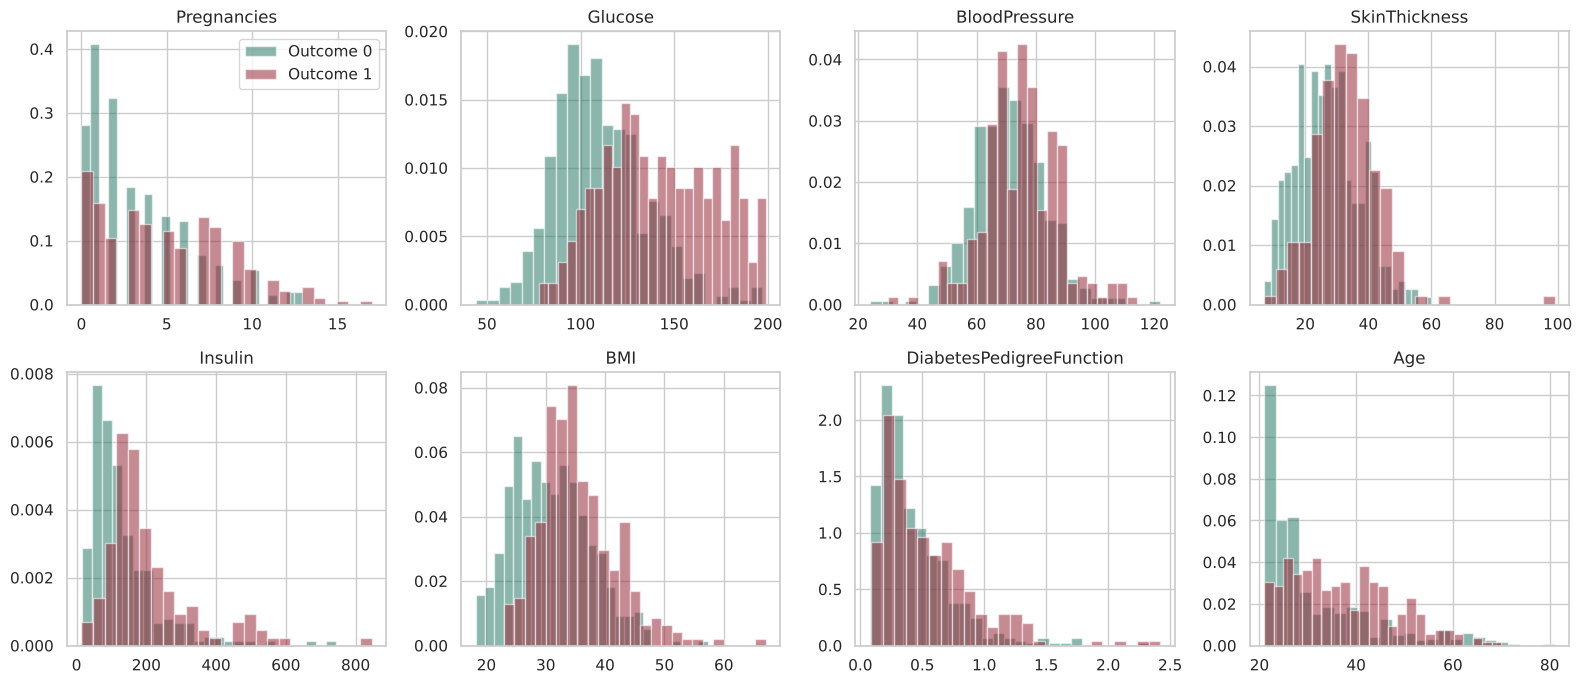

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), CSV_COLUMNS):
    for cls, color in [(0, "#2d7a68"), (1, "#972a3a")]:
        ax.hist(clean.loc[df.Outcome == cls, col].dropna(), bins=25, alpha=.55, density=True, color=color, label=f"Outcome {cls}")
    ax.set_title(col)
axes[0, 0].legend(); plt.tight_layout(); plt.show()

In [4]:
clean.groupby(df.Outcome)[CSV_COLUMNS].median().T.rename(columns={0: "median, non-diabetic", 1: "median, diabetic"})

Outcome,"median, non-diabetic","median, diabetic"
Pregnancies,2.000,4.000
Glucose,107.000,140.000
BloodPressure,70.000,74.500
SkinThickness,27.000,32.000
Insulin,102.500,169.500
BMI,30.100,34.300
DiabetesPedigreeFunction,0.336,0.449
Age,27.000,36.000


## Outlier analysis (Tukey IQR rule)

In [5]:
q = data_quality_report(df)
pd.DataFrame({k: v["outliers_iqr"] for k, v in q["feature_stats"].items()}).T[["lower_fence", "upper_fence", "n_outliers", "pct_outliers"]]

,lower_fence,upper_fence,n_outliers,pct_outliers
pregnancies,-6.500,13.500,4.0,0.52
glucose,36.000,204.000,0.0,0.00
blood_pressure,40.000,104.000,14.0,1.91
skin_thickness,1.000,57.000,3.0,0.55
insulin,-94.375,360.625,24.0,6.09
bmi,13.850,50.250,8.0,1.06
diabetes_pedigree,-0.330,1.200,29.0,3.78
age,-1.500,66.500,9.0,1.17


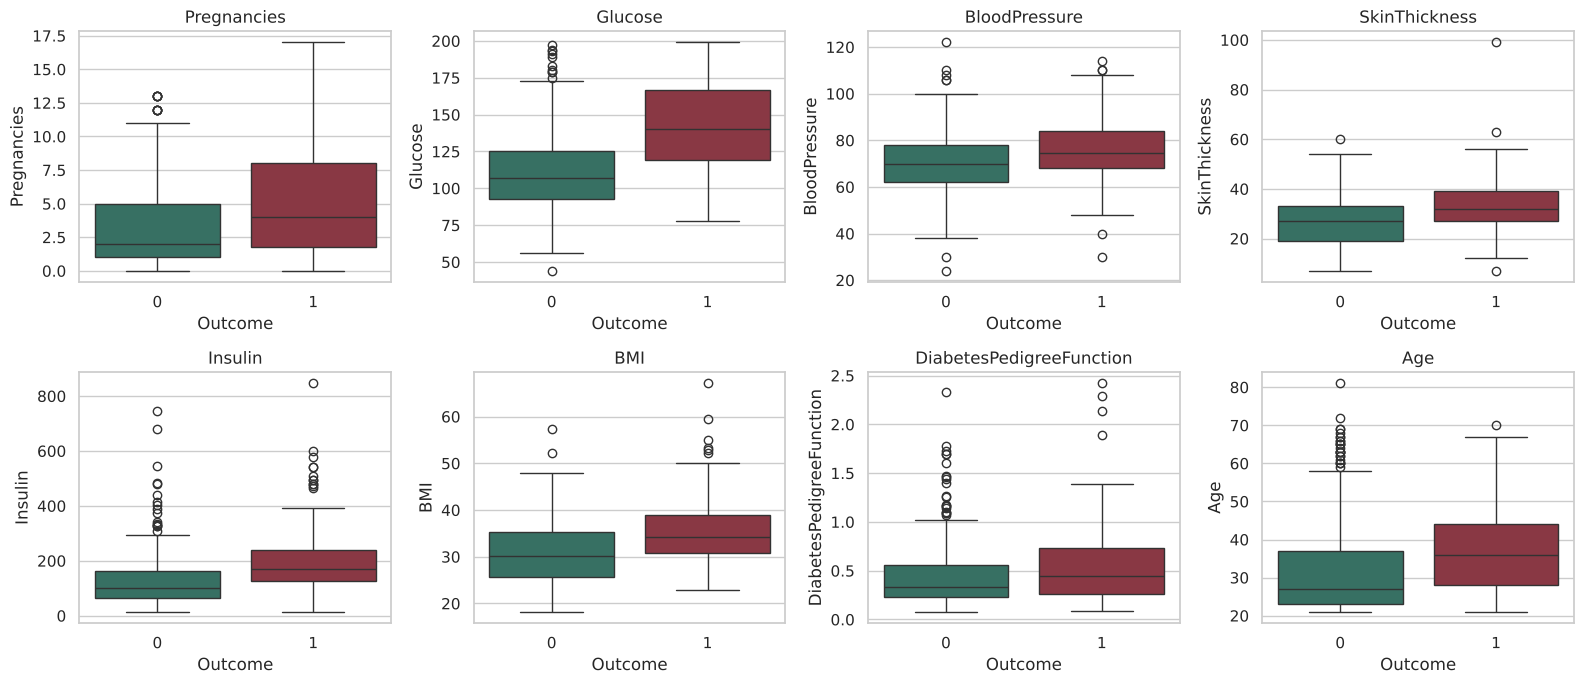

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), CSV_COLUMNS):
    sns.boxplot(x=df.Outcome, y=clean[col], ax=ax, hue=df.Outcome, legend=False, palette=["#2d7a68", "#972a3a"]); ax.set_title(col)
plt.tight_layout(); plt.show()

> **Decision:** outliers are reported but not removed — the dataset is small and extreme values (e.g. high insulin) are clinically plausible.

## Correlation analysis

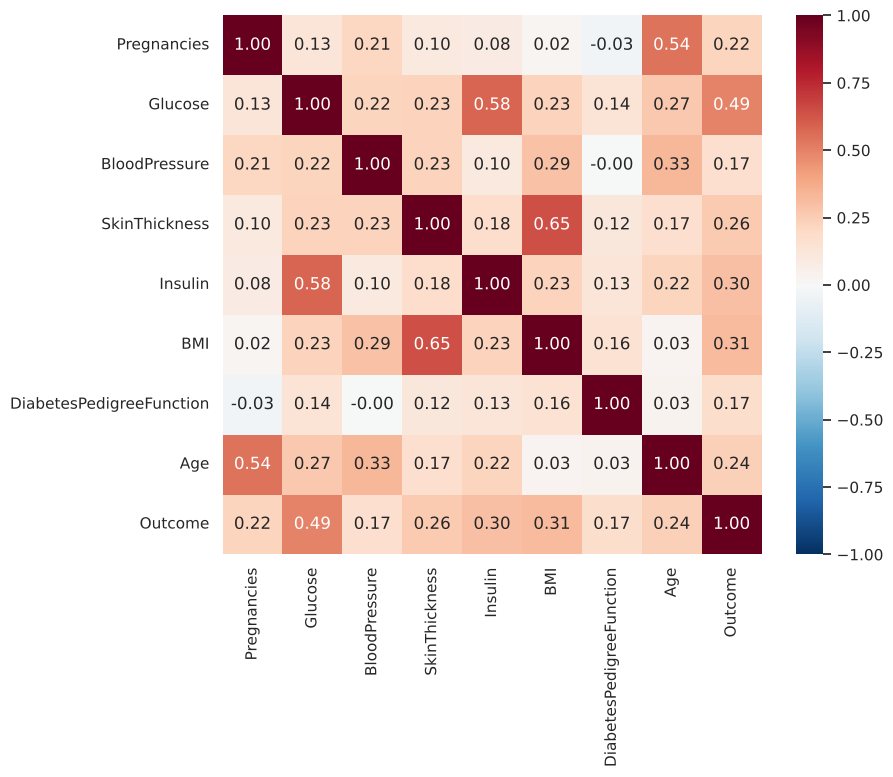

Glucose                     0.495
BMI                         0.314
Insulin                     0.303
SkinThickness               0.259
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
BloodPressure               0.171
Name: Outcome, dtype: float64

In [7]:
corr = clean[CSV_COLUMNS + ["Outcome"]].corr()
plt.figure(figsize=(9, 7)); sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True); plt.show()
corr["Outcome"].drop("Outcome").sort_values(ascending=False).round(3)

**Takeaways:** Glucose has the strongest association with the outcome, followed by BMI, Age, Insulin and Pregnancies. Age and Pregnancies are correlated (≈0.54), as are BMI and SkinThickness — mild multicollinearity, handled by regularisation in linear models.